 Step 1: Loading the Dataset

In this step, we load the air quality dataset containing hourly pollution readings
across major Indian cities from 2022 to 2025.
The dataset includes pollutants like PM2.5, PM10, NO2, CO, and O3 along with
weather parameters like temperature, humidity, and wind speed.

In [1]:
import pandas as pd

df = pd.read_csv("INDIA_AQI_COMPLETE_20251126.csv")

df.head()

,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Inversion_Strength_C,Festival_Period,Crop_Burning_Season
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Data columns (total 71 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   City                   842160 non-null  object 
 1   State                  842160 non-null  object 
 2   Latitude               842160 non-null  float64
 3   Longitude              842160 non-null  float64
 4   Datetime               842160 non-null  object 
 5   Year                   842160 non-null  int64  
 6   Month                  842160 non-null  int64  
 7   Day                    842160 non-null  int64  
 8   Hour                   842160 non-null  int64  
 9   Day_of_Week            842160 non-null  int64  
 10  Day_Name               842160 non-null  object 
 11  Week_of_Year           842160 non-null  int64  
 12  Is_Weekend             842160 non-null  int64  
 13  Quarter                842160 non-null  int64  
 14  Season                 842160 non-nu

Step 2: Data Preprocessing

We select only the relevant columns needed for our analysis and drop the rest
to keep the dataset clean and focused.

In [3]:
# Select important columns

df = df[[
    'City',
    'Datetime',
    'Year',
    'Month',
    'AQI_Category',
    'PM2_5_ugm3',
    'PM10_ugm3',
    'NO2_ugm3',
    'CO_ugm3',
    'O3_ugm3',
    'Temp_2m_C',
    'Humidity_Percent',
    'Wind_Speed_10m_kmh'
]]

# Check new dataset
df.head()

,City,Datetime,Year,Month,AQI_Category,PM2_5_ugm3,PM10_ugm3,NO2_ugm3,CO_ugm3,O3_ugm3,Temp_2m_C,Humidity_Percent,Wind_Speed_10m_kmh
0,Agartala,2022-08-05 00:00:00,2022,8,NaN,14.8,21.5,21.8,197.0,32.0,26.7,91,5.4
1,Agartala,2022-08-05 01:00:00,2022,8,NaN,15.7,22.8,18.5,196.0,33.0,26.4,93,4.5
2,Agartala,2022-08-05 02:00:00,2022,8,NaN,16.3,23.5,15.1,196.0,34.0,26.1,95,3.8
3,Agartala,2022-08-05 03:00:00,2022,8,NaN,17.6,25.4,14.1,197.0,32.0,26.0,96,3.7
4,Agartala,2022-08-05 04:00:00,2022,8,NaN,18.2,26.2,13.9,199.0,30.0,25.8,97,4.1


### Handling Missing Values

We first check for null values across all columns.
Since AQI_Category is our primary target variable, we drop rows where it is missing.
Other columns with nulls are retained as they may still be useful for pollutant analysis.

In [4]:
df.isnull().sum()


,0
City,0
Datetime,0
Year,0
Month,0
AQI_Category,2516
PM2_5_ugm3,0
PM10_ugm3,0
NO2_ugm3,0
CO_ugm3,0
O3_ugm3,0


In [5]:
df = df.dropna(subset=['AQI_Category'])

# Check again
df.isnull().sum()


,0
City,0
Datetime,0
Year,0
Month,0
AQI_Category,0
PM2_5_ugm3,0
PM10_ugm3,0
NO2_ugm3,0
CO_ugm3,0
O3_ugm3,0


### Extracting Time Components

We convert the Datetime column to proper datetime format and extract
Hour, Day, and Month as separate columns.
This allows us to analyze pollution trends across different time periods.

In [6]:
df['Datetime'] = pd.to_datetime(df['Datetime'])


In [7]:
df['Hour'] = df['Datetime'].dt.hour
df['Day'] = df['Datetime'].dt.day
df['Month'] = df['Datetime'].dt.month

In [8]:
df.head()

,City,Datetime,Year,Month,AQI_Category,PM2_5_ugm3,PM10_ugm3,NO2_ugm3,CO_ugm3,O3_ugm3,Temp_2m_C,Humidity_Percent,Wind_Speed_10m_kmh,Hour,Day
5,Agartala,2022-08-05 05:00:00,2022,8,Moderate,19.1,27.6,16.4,210.0,26.0,26.6,95,4.3,5,5
6,Agartala,2022-08-05 06:00:00,2022,8,Moderate,16.2,23.6,15.6,197.0,31.0,27.9,89,3.4,6,5
7,Agartala,2022-08-05 07:00:00,2022,8,Moderate,12.0,17.7,14.5,180.0,39.0,29.3,82,4.0,7,5
8,Agartala,2022-08-05 08:00:00,2022,8,Moderate,10.1,14.9,12.8,160.0,50.0,30.4,78,6.1,8,5
9,Agartala,2022-08-05 09:00:00,2022,8,Moderate,10.9,16.1,10.9,153.0,60.0,31.2,73,3.5,9,5


## Step 3: Exploratory Data Analysis (EDA)

### AQI Category Distribution

We analyze how air quality is distributed across different AQI categories
to understand the overall pollution scenario in Indian cities.

In [9]:
df['AQI_Category'].value_counts()

,count
AQI_Category,
Moderate,385769
Unhealthy_Sensitive,175071
Good,136459
Unhealthy,130352
Very_Unhealthy,10354
Hazardous,1639


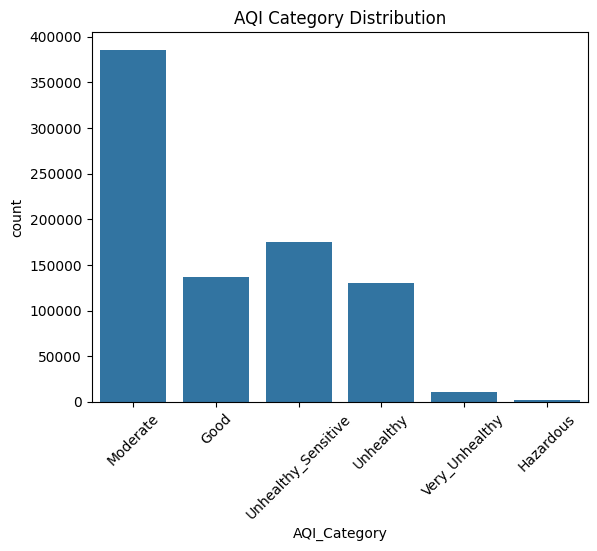

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='AQI_Category')
plt.title("AQI Category Distribution")
plt.xticks(rotation=45)
plt.show()

### City-wise Pollution Analysis

We calculate the average PM2.5 levels for each city to identify
the most polluted urban areas in India.
PM2.5 is chosen as the primary indicator as it is the most harmful
pollutant for human health and has the strongest impact on AQI.

In [11]:
city_aqi = df.groupby('City')['PM2_5_ugm3'].mean().sort_values(ascending=False)

city_aqi.head(10)

,PM2_5_ugm3
City,
Gurugram,73.462139
Delhi,70.374027
Patna,59.898171
Kolkata,57.044174
Lucknow,56.292891
Raipur,50.474128
Mumbai,41.418829
Agartala,41.277017
Chandigarh,40.804670


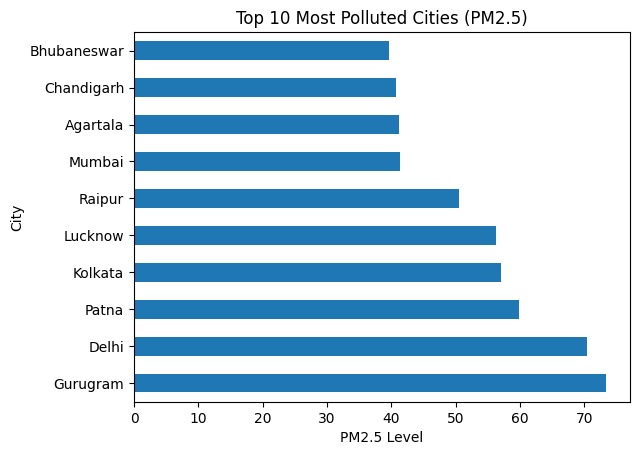

In [12]:
city_aqi.head(10).plot(kind='barh')
plt.title("Top 10 Most Polluted Cities (PM2.5)")
plt.xlabel("PM2.5 Level")
plt.show()

### Monthly Pollution Trend

We analyze how PM2.5 levels vary across months to detect seasonal patterns.
Higher pollution in winter months (Nov–Jan) is expected due to temperature
inversion, crop burning, and reduced wind speeds.

In [13]:
monthly_trend = df.groupby('Month')['PM2_5_ugm3'].mean()

monthly_trend

,PM2_5_ugm3
Month,
1,58.688581
2,43.543690
3,37.859472
4,31.602572
5,28.891205
6,25.560052
7,18.772508
8,20.334824
9,21.956305


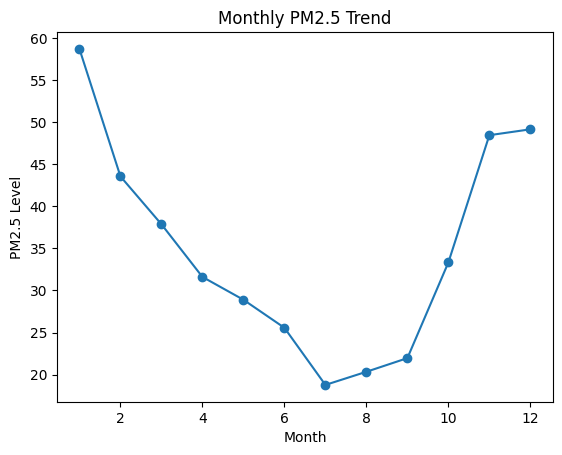

In [14]:
monthly_trend.plot(marker='o')
plt.title("Monthly PM2.5 Trend")
plt.xlabel("Month")
plt.ylabel("PM2.5 Level")
plt.show()

### Pollutant Correlation Analysis

We examine the correlation between different pollutants to understand
which ones tend to rise and fall together.
A high correlation between PM2.5 and PM10 would suggest a common
source like vehicular emissions or construction dust.

In [15]:
df[['PM2_5_ugm3', 'PM10_ugm3', 'NO2_ugm3', 'CO_ugm3', 'O3_ugm3']].corr()

,PM2_5_ugm3,PM10_ugm3,NO2_ugm3,CO_ugm3,O3_ugm3
PM2_5_ugm3,1.000000,0.788913,0.647953,0.732401,0.052705
PM10_ugm3,0.788913,1.000000,0.491535,0.538591,0.103507
NO2_ugm3,0.647953,0.491535,1.000000,0.784722,-0.355229
CO_ugm3,0.732401,0.538591,0.784722,1.000000,-0.185631
O3_ugm3,0.052705,0.103507,-0.355229,-0.185631,1.000000


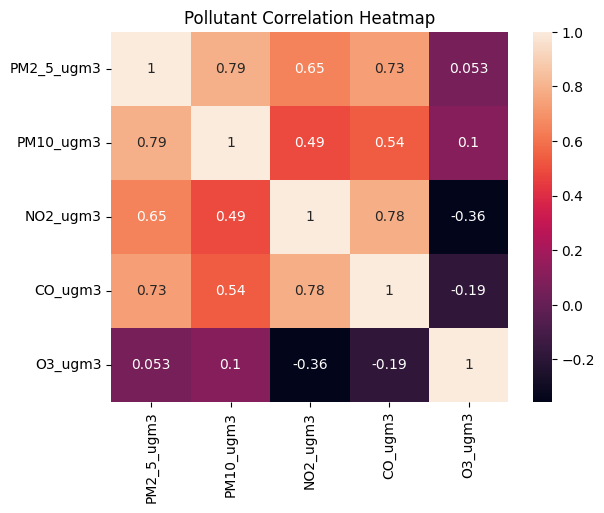

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[['PM2_5_ugm3', 'PM10_ugm3', 'NO2_ugm3', 'CO_ugm3', 'O3_ugm3']].corr(), annot=True)
plt.title("Pollutant Correlation Heatmap")
plt.show()

## Step 4: City Risk Segmentation

We categorize cities into Low, Moderate, and High pollution zones
based on their average PM2.5 levels.
Thresholds used: below 30 = Low, 30–60 = Moderate, above 60 = High
(based on WHO interim air quality guidelines).

In [17]:
city_avg = df.groupby('City')['PM2_5_ugm3'].mean().reset_index()

city_avg.head()

,City,PM2_5_ugm3
0,Agartala,41.277017
1,Ahmedabad,29.946137
2,Aizawl,17.899387
3,Bengaluru,20.392213
4,Bhopal,28.094669


In [18]:
def categorize(pm):
    if pm < 30:
        return "Low"
    elif pm < 60:
        return "Moderate"
    else:
        return "High"

city_avg['Pollution_Level'] = city_avg['PM2_5_ugm3'].apply(categorize)

city_avg.sort_values(by='PM2_5_ugm3', ascending=False)

,City,PM2_5_ugm3,Pollution_Level
11,Gurugram,73.462139,High
9,Delhi,70.374027,High
22,Patna,59.898171,Moderate
18,Kolkata,57.044174,Moderate
19,Lucknow,56.292891,Moderate
23,Raipur,50.474128,Moderate
20,Mumbai,41.418829,Moderate
0,Agartala,41.277017,Moderate
6,Chandigarh,40.804670,Moderate
5,Bhubaneswar,39.702528,Moderate


## Step 5: SQL Analysis using SQLite

We load the cleaned dataframe into a SQLite database to perform
structured queries. SQL allows us to efficiently aggregate, filter,
and rank data — skills commonly used in real-world data workflows.

In [19]:
import sqlite3

conn = sqlite3.connect("aqi.db")

df.to_sql("aqi_data", conn, if_exists="replace", index=False)

839644

### Query 1 — AQI Category Distribution

In [20]:
query = """
SELECT AQI_Category, COUNT(*) as count
FROM aqi_data
GROUP BY AQI_Category
ORDER BY count DESC
"""

import pandas as pd
pd.read_sql(query, conn)

,AQI_Category,count
0,Moderate,385769
1,Unhealthy_Sensitive,175071
2,Good,136459
3,Unhealthy,130352
4,Very_Unhealthy,10354
5,Hazardous,1639


### Query 2 — Top 10 Most Polluted Cities

In [21]:
query = """
SELECT City, AVG(PM2_5_ugm3) as avg_pm25
FROM aqi_data
GROUP BY City
ORDER BY avg_pm25 DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,City,avg_pm25
0,Gurugram,73.462139
1,Delhi,70.374027
2,Patna,59.898171
3,Kolkata,57.044174
4,Lucknow,56.292891
5,Raipur,50.474128
6,Mumbai,41.418829
7,Agartala,41.277017
8,Chandigarh,40.804670
9,Bhubaneswar,39.702528


### Query 3 — Monthly Pollution Trend by City

In [22]:
query = """
SELECT City, Month, ROUND(AVG(PM2_5_ugm3), 2) as avg_pm25
FROM aqi_data
GROUP BY City, Month
ORDER BY City, Month
"""

monthly_city_trend = pd.read_sql(query, conn)
monthly_city_trend.head(20)

,City,Month,avg_pm25
0,Agartala,1,84.02
1,Agartala,2,72.52
2,Agartala,3,55.03
3,Agartala,4,45.20
4,Agartala,5,35.72
5,Agartala,6,22.16
6,Agartala,7,11.77
7,Agartala,8,15.69
8,Agartala,9,20.78
9,Agartala,10,38.26


### Query 4 — City Pollution Ranking by Month (Window Function)

In [23]:
query = """
SELECT City, Month, ROUND(AVG(PM2_5_ugm3), 2) as avg_pm25,
       RANK() OVER (PARTITION BY Month ORDER BY AVG(PM2_5_ugm3) DESC) as pollution_rank
FROM aqi_data
GROUP BY City, Month
"""

ranked = pd.read_sql(query, conn)

# Show top ranked city per month
ranked[ranked['pollution_rank'] == 1].sort_values('Month')

,City,Month,avg_pm25,pollution_rank
0,Gurugram,1,126.59,1
29,Kolkata,2,77.78,1
58,Gurugram,3,67.86,1
87,Gurugram,4,53.14,1
116,Delhi,5,62.85,1
145,Delhi,6,57.25,1
174,Delhi,7,48.17,1
203,Delhi,8,47.09,1
232,Gurugram,9,48.82,1
261,Gurugram,10,73.89,1


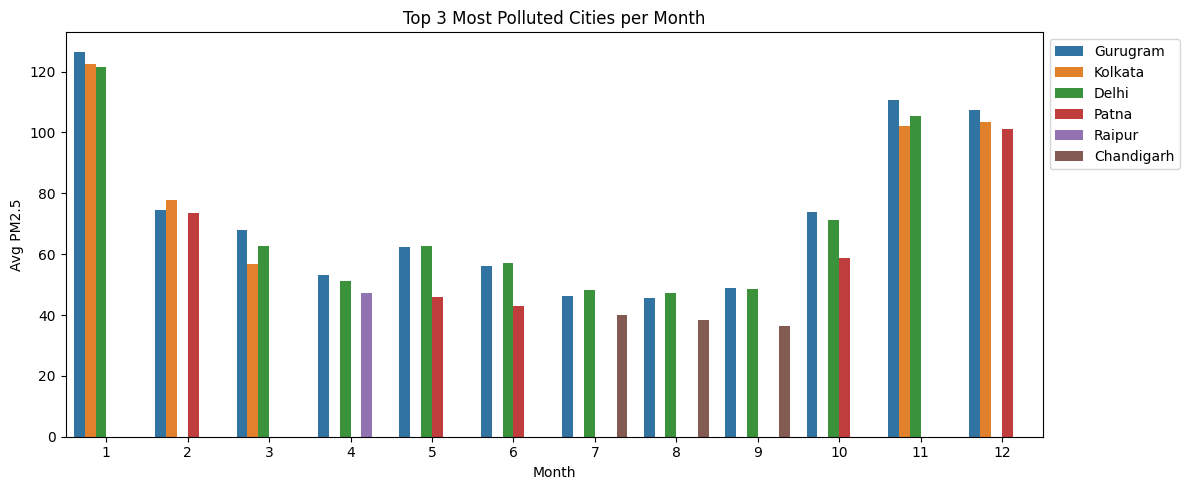

In [24]:
# Visualize top 3 cities per month
top3 = ranked[ranked['pollution_rank'] <= 3]

plt.figure(figsize=(12,5))
sns.barplot(data=top3, x='Month', y='avg_pm25', hue='City')
plt.title("Top 3 Most Polluted Cities per Month")
plt.xlabel("Month")
plt.ylabel("Avg PM2.5")
plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


##  Conclusion

This analysis reveals strong seasonal and regional patterns in Indian urban air quality:
- Pollution peaks during winter months, especially November to January
- Northern cities like Delhi and Gurugram consistently show the highest PM2.5 levels
- PM2.5 and PM10 are strongly correlated, pointing to common pollution sources
- Southern and northeastern cities generally maintain better air quality

Targeted policy interventions during winter months in northern cities
could significantly improve public health outcomes.